# v13 — BMF20: เลือกหุ้น 20 ตัวจาก "ความถูก" (BM) + "ความแข็งแรงของงบ" (F-score) และลงทุน 5 แบบ

> ข้อมูลอธิบาย + การประเมินตามเกณฑ์ของ round 013 · ช่วงข้อมูล มิ.ย. 2011 – 30 มิ.ย. 2023 (held-out ตั้งแต่ ก.ค. 2023 **ไม่ถูกใช้**)

## 2 กฎเลือกหุ้น (อุปมา: คัดนักวิ่ง 20 คนจากนักวิ่ง ~170–355 คน)
- **BM (book-to-market)** = มูลค่าทางบัญชี ÷ มูลค่าตลาด → ยิ่งสูง หุ้นยิ่ง "ถูก" เทียบกับทรัพย์สินที่บริษัทมี (เหมือนนักวิ่งค่าตัวถูก)
- **F-score (Piotroski 0–9)** = เช็กลิสต์ 9 ข้อว่างบการเงินแข็งแรงขึ้นไหม (กำไร, เงินสด, หนี้, สภาพคล่อง, ประสิทธิภาพ) → เหมือนผลตรวจสุขภาพ
- **S1 คัดสองชั้น (FUNNEL):** เอา 100 คนค่าตัวถูกที่สุดก่อน แล้วเลือก 20 คนที่สุขภาพดีที่สุดใน 100 คนนั้น → "ถูก" มาก่อน แล้วค่อยดูสุขภาพ
- **S2 ให้คะแนนรวม (WEIGHTED):** ทุกคนได้คะแนน = 60% ความถูก + 40% สุขภาพ (วัดเป็นอันดับเปอร์เซ็นไทล์) แล้วเลือก 20 คะแนนสูงสุด → คนที่ถูกปานกลางแต่สุขภาพดีมากก็มีโอกาส

## 5 แบบการลงทุน (อุปมา: รายชื่อ 20 ตัวคือ "เมนูประจำปี" ที่เปลี่ยนทุก มิ.ย.)
| แบบ | เงินเข้า | ทำอะไร | อุปมา |
|---|---|---|---|
| **Y1_KEEP** | ก้อนเท่ากันทุก มิ.ย. | เงินใหม่ซื้อเมนูปีนี้ ของเดิมเก็บไว้ไม่ขาย | สั่งจานใหม่ทุกปี ไม่ทิ้งจานเก่า → จานบนโต๊ะเพิ่มเรื่อย ๆ |
| **Y2_SWITCH** | ก้อนเท่ากันทุก มิ.ย. | ปรับทั้งพอร์ตเป็นเมนูปีนี้ 20 ตัวเท่ากัน (ซื้อขายเฉพาะส่วนต่าง) | เปลี่ยนทั้งโต๊ะเป็นเมนูใหม่ทุกปี |
| **Y3_BUYHOLD** | ก้อนเดียวปีแรก | ซื้อเมนูปีแรก ถือไม่แตะจนจบ | สั่งครั้งเดียวแล้วนั่งกินยาว |
| **M1_KEEP** | เท่ากันทุกสิ้นเดือน (DCA) | เงินใหม่ซื้อเมนูล่าสุด ไม่ขาย | เติมจานทุกเดือน ไม่ทิ้งอะไร |
| **M2_SWITCH** | เท่ากันทุกสิ้นเดือน (DCA) | เหมือน M1 + ทุก มิ.ย. ขายตัวที่หลุดเมนูใหม่ แล้วซื้อเมนูใหม่ | เติมทุกเดือน และเก็บจานที่ไม่อยู่ในเมนูใหม่ทุก มิ.ย. |

ตัวเทียบใช้กระแสเงิน **แบบเดียวกันทุกโหมด**: SPY, EW (ซื้อทุกตัวใน universe เท่ากัน), v1 P3 (BM quintile บน + F ≥ 7)
· ต้นทุน 10 bps ต่อการซื้อ/ขาย · **มีเพียง Y2 แบบลงก้อนเดียวไม่เติมเงินที่ใช้ตัดสินตามเกณฑ์ S1–S7** — โหมดอื่นเป็นข้อมูลอธิบาย ห้ามใช้เลือกกฎ


In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
from rounds.round_013 import report as rp
report.banner()
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 200)
D = pathlib.Path("../rounds/round_013")
res, m, y3 = pd.read_csv(D / "results.csv"), pd.read_csv(D / "modes_main.csv"), pd.read_csv(D / "modes_y3_all_starts.csv")
sc = pd.read_csv(D / "scores.csv", parse_dates=["R"])
print("จำนวนหุ้นใน universe ต่อปี:", {d.year: n for d, n in sc.groupby("R").size().items()})

/Users/boeing/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


จำนวนหุ้นใน universe ต่อปี: {2011: 169, 2012: 238, 2013: 259, 2014: 266, 2015: 275, 2016: 290, 2017: 297, 2018: 306, 2019: 306, 2020: 319, 2021: 344, 2022: 355}


## 1) ผลตามเกณฑ์ S1–S7 (Y2_SWITCH ลงก้อนเดียวไม่เติมเงิน = backtest มาตรฐาน)

trial_id,r013_BMF20_FUNNEL,r013_BMF20_WEIGHTED
dec_sharpe,0.405181,0.415205
dec_sharpe_ew,0.640013,0.640013
dec_sharpe_spy,0.68109,0.68109
dec_cagr,0.088986,0.095653
dec_cagr_ew,0.125075,0.125075
dec_maxdd,-0.506883,-0.55209
dec_maxdd_ew,-0.375788,-0.375788
dec_active_ann,-0.018342,-0.005238
dec_nw_t,-0.409894,-0.094793
S1_10,False,False


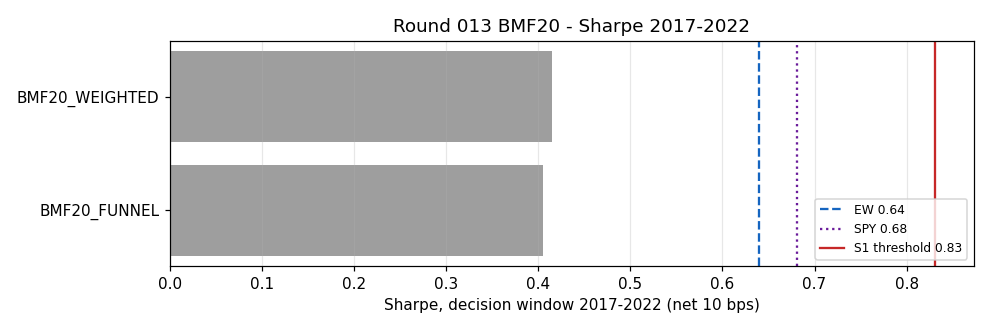

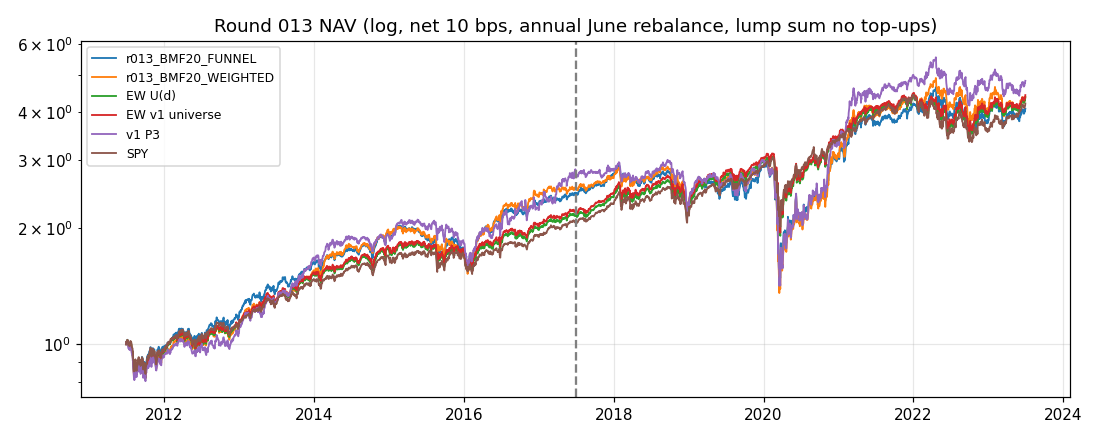

In [2]:
cols = ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew","dec_active_ann","dec_nw_t",
        "S1_10","S1_25","S2_share","DSR","N_trials","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew","info_cagr","info_cagr_ew"]
display(res[cols].set_index("trial_id").T.round(3))
display(Image(filename="../figures/round_013_sharpe.png")); display(Image(filename="../figures/round_013_nav.png"))

## 2) ตารางหลัก: เงิน 1 บาทที่ใส่ → กี่บาท · ผลตอบแทนต่อปี (XIRR; Y3 = CAGR)

In [3]:
for s in ("2011-06-30", "2017-06-30"):
    display(Markdown(f"**จุดเริ่ม {s[:7]}**\n\n" + rp.main_table(m, s)))

**จุดเริ่ม 2011-06**

| กลยุทธ์ | Y1 ก้อนรายปี สะสมไม่ขาย | Y2 ก้อนรายปี ย้ายทั้งพอร์ต | Y3 ก้อนเดียว ถือยาว | M1 DCA สะสมไม่ขาย | M2 DCA ย้ายทุก มิ.ย. |
|---|---|---|---|---|---|
| S1 คัดสองชั้น (BM 100 ตัวแรก → F 20 ตัว) | 2.62 · 14.1%/ปี | 2.18 · 11.5%/ปี | 5.76 · 15.7%/ปี | 2.42 · 13.9%/ปี | 1.94 · 10.5%/ปี |
| S2 คะแนน 0.6·BM + 0.4·F (20 ตัว) | 2.95 · 15.9%/ปี | 2.33 · 12.5%/ปี | 4.33 · 13.0%/ปี | 2.70 · 15.5%/ปี | 2.14 · 12.0%/ปี |
| SPY | 2.36 · 12.6%/ปี | 2.36 · 12.6%/ปี | 4.21 · 12.7%/ปี | 2.24 · 12.7%/ปี | 2.24 · 12.7%/ปี |
| EW ทั้ง universe (ถือทุกตัวเท่ากัน) | 2.55 · 13.8%/ปี | 2.40 · 12.9%/ปี | 4.98 · 14.3%/ปี | 2.43 · 13.9%/ปี | 2.46 · 14.1%/ปี |
| v1 P3 (BM quintile บน + F ≥ 7) | 1.99 · 10.2%/ปี | 2.54 · 13.7%/ปี | 4.73 · 13.8%/ปี | 1.90 · 10.2%/ปี | 2.05 · 11.3%/ปี |

**จุดเริ่ม 2017-06**

| กลยุทธ์ | Y1 ก้อนรายปี สะสมไม่ขาย | Y2 ก้อนรายปี ย้ายทั้งพอร์ต | Y3 ก้อนเดียว ถือยาว | M1 DCA สะสมไม่ขาย | M2 DCA ย้ายทุก มิ.ย. |
|---|---|---|---|---|---|
| S1 คัดสองชั้น (BM 100 ตัวแรก → F 20 ตัว) | 1.39 · 9.4%/ปี | 1.47 · 11.1%/ปี | 1.74 · 9.7%/ปี | 1.32 · 9.2%/ปี | 1.32 · 9.1%/ปี |
| S2 คะแนน 0.6·BM + 0.4·F (20 ตัว) | 1.41 · 10.0%/ปี | 1.54 · 12.4%/ปี | 1.79 · 10.2%/ปี | 1.35 · 9.8%/ปี | 1.40 · 11.1%/ปี |
| SPY | 1.53 · 12.3%/ปี | 1.53 · 12.3%/ปี | 2.03 · 12.5%/ปี | 1.44 · 11.9%/ปี | 1.44 · 11.9%/ปี |
| EW ทั้ง universe (ถือทุกตัวเท่ากัน) | 1.50 · 11.7%/ปี | 1.54 · 12.4%/ปี | 1.95 · 11.7%/ปี | 1.41 · 11.4%/ปี | 1.42 · 11.6%/ปี |
| v1 P3 (BM quintile บน + F ≥ 7) | 1.38 · 9.3%/ปี | 1.62 · 14.0%/ปี | 1.60 · 8.1%/ปี | 1.29 · 8.3%/ปี | 1.35 · 9.8%/ปี |

## 3) ตัวชี้วัดครบทุกโหมด (TWR = หักผลของเงินที่เติม) และแยกช่วง 2011–2016 / 2017–2023

In [4]:
k = ["start","mode","strategy","final","invested","multiple","xirr","twr_cagr","sharpe","maxdd_twr","maxdd_value","turnover_yr","n_avg","n_end","cash_avg","cash_end"]
display(m[k].round(3))
print("แยกช่วง (จากการรันจุดเริ่ม 2011; ดัชนี time-weighted)")
display(m[m.start == "2011-06-30"][["mode","strategy","info_twr_cagr","info_sharpe","info_maxdd","dec_twr_cagr","dec_sharpe","dec_maxdd"]].round(3))

,start,mode,strategy,final,invested,multiple,xirr,twr_cagr,sharpe,maxdd_twr,maxdd_value,turnover_yr,n_avg,n_end,cash_avg,cash_end
0,2011-06-30,Y1_KEEP,S1_FUNNEL,3141249.348,1200000.0,2.618,0.141,0.142,0.867,-0.383,-0.383,0.000,87.876,142,0.0,0.0
1,2011-06-30,Y1_KEEP,S2_WEIGHTED,3543633.968,1200000.0,2.953,0.159,0.151,0.875,-0.390,-0.390,0.000,80.855,132,0.0,0.0
2,2011-06-30,Y1_KEEP,SPY,2827357.380,1200000.0,2.356,0.126,0.127,0.839,-0.337,-0.337,0.000,1.000,1,0.0,0.0
3,2011-06-30,Y1_KEEP,EW,3063370.573,1200000.0,2.553,0.138,0.138,0.874,-0.349,-0.349,0.000,316.566,410,0.0,0.0
4,2011-06-30,Y1_KEEP,v1_P3,2385051.888,1200000.0,1.988,0.102,0.109,0.648,-0.445,-0.445,0.000,42.441,82,0.0,0.0
5,2011-06-30,Y2_SWITCH,S1_FUNNEL,2614515.766,1200000.0,2.179,0.115,0.124,0.649,-0.507,-0.507,0.708,20.000,20,0.0,0.0
6,2011-06-30,Y2_SWITCH,S2_WEIGHTED,2800476.106,1200000.0,2.334,0.125,0.131,0.643,-0.552,-0.552,0.716,20.000,20,0.0,0.0
7,2011-06-30,Y2_SWITCH,SPY,2827357.380,1200000.0,2.356,0.126,0.127,0.839,-0.337,-0.337,0.000,1.000,1,0.0,0.0
8,2011-06-30,Y2_SWITCH,EW,2881808.177,1200000.0,2.402,0.129,0.132,0.820,-0.377,-0.377,0.096,285.814,355,0.0,0.0
9,2011-06-30,Y2_SWITCH,v1_P3,3052596.394,1200000.0,2.544,0.137,0.140,0.633,-0.529,-0.529,0.767,10.869,28,0.0,0.0


แยกช่วง (จากการรันจุดเริ่ม 2011; ดัชนี time-weighted)


,mode,strategy,info_twr_cagr,info_sharpe,info_maxdd,dec_twr_cagr,dec_sharpe,dec_maxdd
0,Y1_KEEP,S1_FUNNEL,0.149,1.254,-0.188,0.136,0.678,-0.383
1,Y1_KEEP,S2_WEIGHTED,0.146,1.209,-0.203,0.156,0.732,-0.390
2,Y1_KEEP,SPY,0.129,1.123,-0.184,0.125,0.681,-0.337
3,Y1_KEEP,EW,0.140,1.180,-0.199,0.136,0.711,-0.349
4,Y1_KEEP,v1_P3,0.141,1.113,-0.211,0.079,0.398,-0.445
5,Y2_SWITCH,S1_FUNNEL,0.161,1.243,-0.227,0.089,0.405,-0.507
6,Y2_SWITCH,S2_WEIGHTED,0.167,1.282,-0.246,0.096,0.415,-0.552
7,Y2_SWITCH,SPY,0.129,1.123,-0.184,0.125,0.681,-0.337
8,Y2_SWITCH,EW,0.141,1.183,-0.199,0.123,0.630,-0.377
9,Y2_SWITCH,v1_P3,0.183,1.170,-0.241,0.098,0.410,-0.529


## 4) กราฟมูลค่าพอร์ต ÷ เงินที่ใส่ แต่ละโหมด เทียบ SPY และ EW

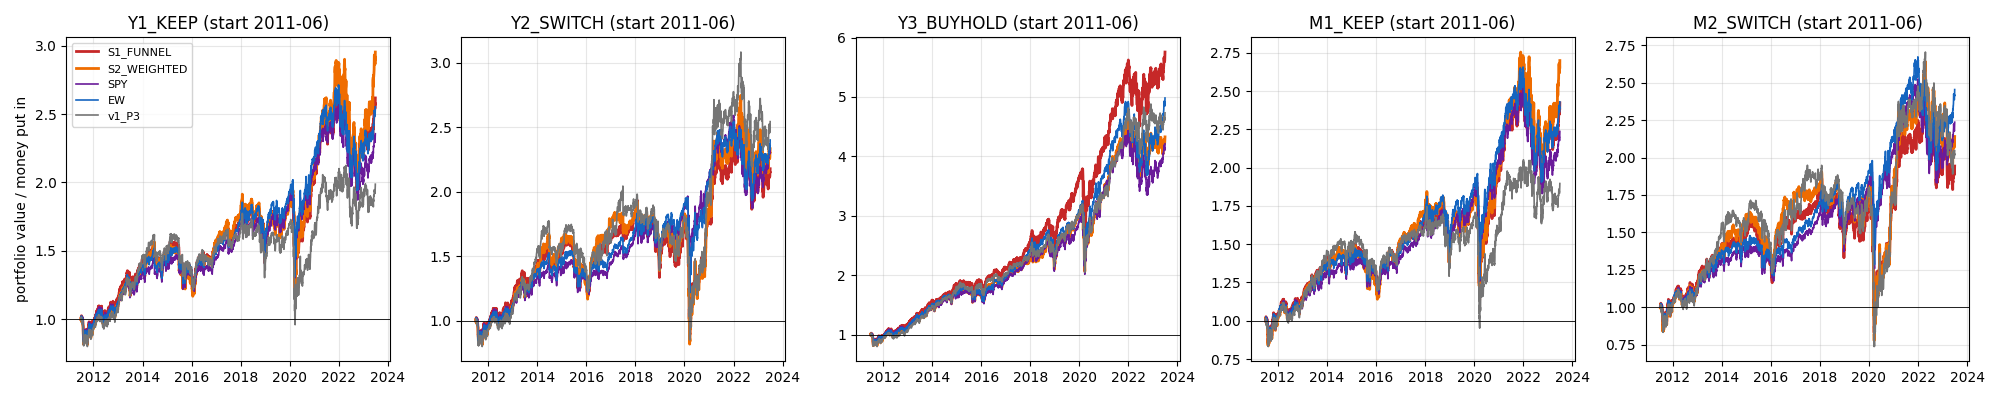

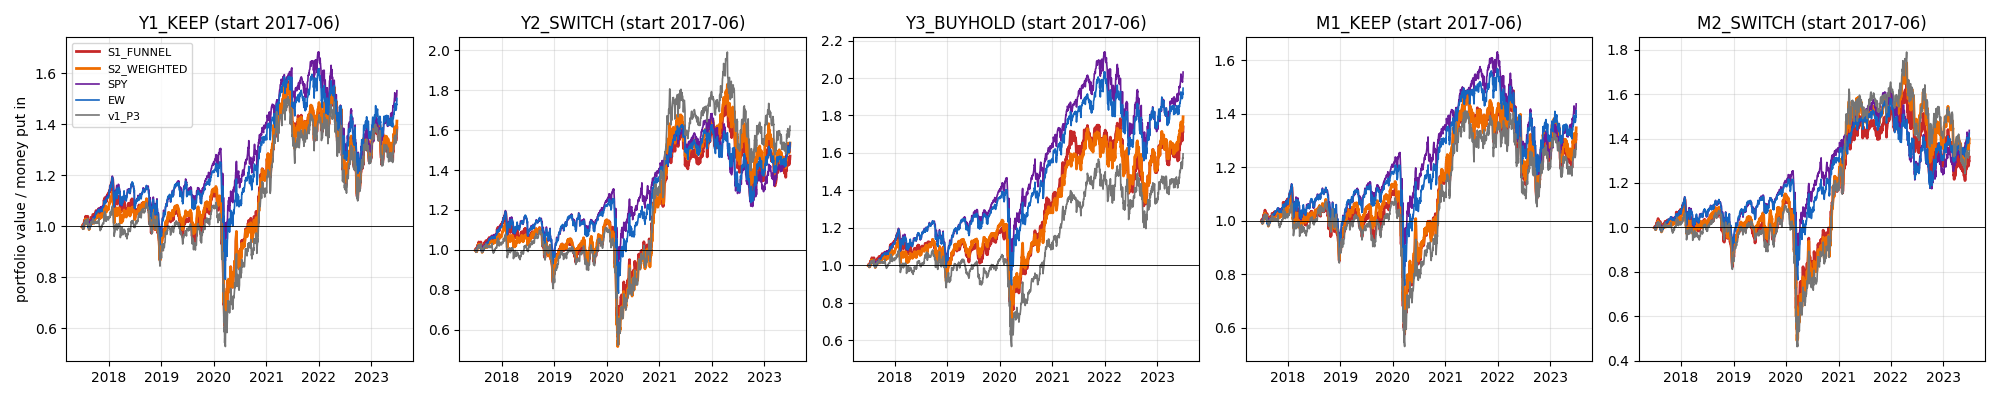

In [5]:
for f in ("round_013_modes_2011.png", "round_013_modes_2017.png"): display(Image(filename=f"../figures/{f}"))

## 5) Y3 ซื้อครั้งเดียวถือยาว ทุกปีเริ่ม 2011–2022 — ขึ้นกับโชคของปีเริ่มแค่ไหน

| ปีเริ่ม (ถือถึง 30 มิ.ย. 2023) | S1_FUNNEL | S2_WEIGHTED | SPY | EW | v1_P3 |
|---|---|---|---|---|---|
| 2011-06 | 15.7% | 13.0% | 12.7% | 14.3% | 13.8% |
| 2012-06 | 11.7% | 12.6% | 13.4% | 15.3% | 13.9% |
| 2013-06 | 10.9% | 24.7% | 12.7% | 14.5% | 8.4% |
| 2014-06 | 6.7% | 7.1% | 11.5% | 12.8% | 5.9% |
| 2015-06 | 28.6% | 26.1% | 12.1% | 13.1% | 9.8% |
| 2016-06 | 9.3% | 7.2% | 13.3% | 13.1% | -5.9% |
| 2017-06 | 9.7% | 10.2% | 12.5% | 11.7% | 8.1% |
| 2018-06 | 4.7% | 3.2% | 12.2% | 10.9% | -0.4% |
| 2019-06 | 9.6% | 9.6% | 12.7% | 11.3% | 7.4% |
| 2020-06 | 21.1% | 25.0% | 14.6% | 17.0% | 30.9% |
| 2021-06 | 3.1% | 3.1% | 3.3% | 2.9% | 2.8% |
| 2022-06 | 4.1% | 5.6% | 19.4% | 18.5% | 6.9% |

,strategy,min,median,max,beat_SPY,beat_EW,n_starts
0,S1_FUNNEL,0.031,0.096,0.286,3,4,12
1,S2_WEIGHTED,0.031,0.099,0.261,4,4,12
2,v1_P3,-0.059,0.078,0.309,3,1,12


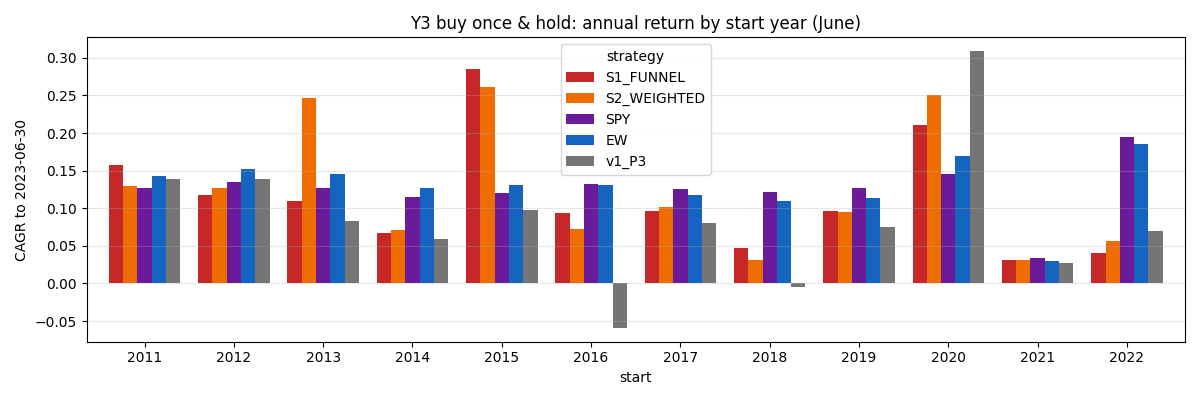

In [6]:
display(Markdown(rp.y3_table(y3))); display(rp.y3_summary(y3).round(3))
display(Image(filename="../figures/round_013_y3_starts.png"))

## 6) รายชื่อ 20 ตัวต่อปี (2017–2022) พร้อมกลุ่มอุตสาหกรรม (SIC) — กระจุกตัวไหม

In [7]:
for rule in ("funnel", "weighted"):
    p = pd.read_csv(D / f"picks_{rule}.csv", parse_dates=["R"])
    q = p[p.R.dt.year >= 2017]
    display(Markdown(f"### {rule}: หุ้นที่เลือก"))
    display(q.assign(ปี=q.R.dt.year).pivot_table(index="rank", columns="ปี", values="ticker", aggfunc="first"))
    display(q.assign(ปี=q.R.dt.year).pivot_table(index="rank", columns="ปี", values="sic_group", aggfunc="first"))
    c = q.groupby([q.R.dt.year, "sic_group"]).size().unstack(fill_value=0)
    print(f"{rule}: จำนวนหุ้นในกลุ่มที่มากที่สุดต่อปี:", c.max(axis=1).to_dict(), "| กลุ่ม:", c.idxmax(axis=1).to_dict())
    display(c.T.sort_values(c.index.max(), ascending=False))
display(Markdown("สัดส่วนกลุ่มใน universe ทั้งหมด (เทียบ): " + ", ".join(f"{k} {v:.0%}" for k, v in sc.groupby("sic_group").size().div(len(sc)).sort_values(ascending=False).head(8).items())))

### funnel: หุ้นที่เลือก

ปี,2017,2018,2019,2020,2021,2022
rank,,,,,,
1,GRMN,PRGO,PVH,ALK,DGX,LUMN
2,PWR,BWA,MU,TPR,CTVA,XRAY
3,GT,RCL,XOM,XRAY,SJM,WHR
4,MDT,KSS,COP,CF,LH,SNA
5,WHR,MDT,CCL,ETN,KR,PVH
6,CHTR,RL,WDC,UAL,DLTR,TAP
7,EIX,CVX,KMI,MGM,UHS,MHK
8,DTE,NCLH,CVX,DAL,MOS,FIS
9,CCL,DTE,FCX,FLS,CVS,GPN


ปี,2017,2018,2019,2020,2021,2022
rank,,,,,,
1,Instruments & medical devices,Chemicals & pharma,Other manufacturing,Transportation,Health services,Communications
2,Construction,Transport equipment,Electronics & semis,Other manufacturing,Chemicals & pharma,Instruments & medical devices
3,Other manufacturing,Transportation,Petroleum refining,Instruments & medical devices,Food & beverage mfg,Electronics & semis
4,Instruments & medical devices,Retail,Petroleum refining,Chemicals (other),Health services,Other manufacturing
5,Electronics & semis,Instruments & medical devices,Transportation,Machinery & computers,Retail,Other manufacturing
6,Communications,Other manufacturing,Machinery & computers,Transportation,Retail,Food & beverage mfg
7,Utilities,Petroleum refining,Utilities,Services (hotels/personal),Health services,Other manufacturing
8,Utilities,Transportation,Petroleum refining,Transportation,Chemicals (other),Business services & software
9,Transportation,Utilities,Mining (metals/coal),Machinery & computers,Retail,Business services & software


funnel: จำนวนหุ้นในกลุ่มที่มากที่สุดต่อปี: {2017: 4, 2018: 5, 2019: 3, 2020: 5, 2021: 3, 2022: 3} | กลุ่ม: {2017: 'Utilities', 2018: 'Other manufacturing', 2019: 'Electronics & semis', 2020: 'Transportation', 2021: 'Health services', 2022: 'Business services & software'}


R,2017,2018,2019,2020,2021,2022
sic_group,,,,,,
Business services & software,0,0,0,0,0,3
Chemicals & pharma,1,1,0,0,2,3
Other manufacturing,3,5,2,2,0,3
Electronics & semis,1,0,3,0,0,2
Food & beverage mfg,0,0,0,0,2,2
Instruments & medical devices,2,2,1,2,2,2
Chemicals (other),0,0,0,1,1,1
Communications,1,0,0,1,1,1
Health services,0,0,0,2,3,1


...

ปี,2017,2018,2019,2020,2021,2022
rank,,,,,,
1,PWR,PRGO,PVH,ALK,CTVA,LUMN
2,CHTR,CVX,CCL,UAL,MOS,PVH
3,GT,NCLH,MU,TPR,SJM,TAP
4,EIX,RCL,WDC,MGM,CVS,XRAY
5,CCL,DTE,KMI,DAL,UHS,MHK
6,GLW,BWA,XOM,NCLH,DGX,FIS
7,M,KSS,CVX,XRAY,PEG,GPN
8,NWSA,MDT,FCX,COP,BIO,DXC
9,DTE,CVS,NUE,JCI,KHC,MU


ปี,2017,2018,2019,2020,2021,2022
rank,,,,,,
1,Construction,Chemicals & pharma,Other manufacturing,Transportation,Chemicals & pharma,Communications
2,Communications,Petroleum refining,Transportation,Transportation,Chemicals (other),Other manufacturing
3,Other manufacturing,Transportation,Electronics & semis,Other manufacturing,Food & beverage mfg,Food & beverage mfg
4,Utilities,Transportation,Machinery & computers,Services (hotels/personal),Retail,Instruments & medical devices
5,Transportation,Utilities,Utilities,Transportation,Health services,Other manufacturing
6,Other manufacturing,Transport equipment,Petroleum refining,Transportation,Health services,Business services & software
7,Retail,Retail,Petroleum refining,Instruments & medical devices,Utilities,Business services & software
8,Other manufacturing,Instruments & medical devices,Mining (metals/coal),Petroleum refining,Instruments & medical devices,Business services & software
9,Utilities,Retail,Other manufacturing,Machinery & computers,Food & beverage mfg,Electronics & semis


weighted: จำนวนหุ้นในกลุ่มที่มากที่สุดต่อปี: {2017: 5, 2018: 4, 2019: 4, 2020: 5, 2021: 3, 2022: 3} | กลุ่ม: {2017: 'Utilities', 2018: 'Utilities', 2019: 'Petroleum refining', 2020: 'Transportation', 2021: 'Health services', 2022: 'Business services & software'}


R,2017,2018,2019,2020,2021,2022
sic_group,,,,,,
Business services & software,1,0,0,0,0,3
Chemicals & pharma,0,2,0,0,2,3
Electronics & semis,1,0,2,1,0,2
Food & beverage mfg,0,0,0,1,2,2
Machinery & computers,1,0,3,3,0,2
Transport equipment,0,1,0,0,1,2
Other manufacturing,4,3,2,3,0,2
Chemicals (other),0,0,0,1,1,1
Communications,1,1,0,0,1,1


สัดส่วนกลุ่มใน universe ทั้งหมด (เทียบ): Business services & software 10%, Retail 10%, Instruments & medical devices 10%, Utilities 9%, Other manufacturing 9%, Machinery & computers 7%, Chemicals & pharma 6%, Electronics & semis 6%

## สรุป (ภาษาง่าย)

**ระดับผล: S1_FUNNEL = C, S2_WEIGHTED = C** (ไม่มีกฎใดผ่านเกณฑ์ "ชนะขาดรอย")
- ช่วงตัดสิน 2017–2023 (ปรับพอร์ตปีละครั้งตามกฎมาตรฐาน): Sharpe 0.41 และ 0.42 เทียบตลาดเฉลี่ย EW 0.64 และ SPY 0.68
  → แพ้ทั้งคู่; กำไร 8.9% / 9.6% ต่อปี เทียบ EW 12.5%; ขาดทุนหนักสุด -51% / -55% เทียบ EW -38%
- ช่วง 2011–2016 กลับชนะ EW (Sharpe 1.25 / 1.28 เทียบ 1.14) → ผลขึ้นกับยุค ไม่ทนทาน
- DSR 0.001 / 0.003 (ต้อง ≥ 0.95) และถือแค่ 20 ตัว (เกณฑ์ S6 ต้อง ≥ 30) → ตกโดยโครงสร้างอยู่แล้ว

**อุปมา:** เหมือนเลือกนักวิ่ง "ค่าตัวถูก + สุขภาพดี" 20 คน — ช่วงปี 2011–2016 ทีมนี้วิ่งดี แต่ช่วง 2017–2023 สนามเปลี่ยนเป็นยุคที่นักวิ่งค่าตัวแพง (หุ้นเติบโต) ชนะ
ทีมที่คัดมาจึงตามหลัง และเพราะมีแค่ 20 คน วันที่ทีมล้มก็ล้มหนักกว่าทีมใหญ่

**ข้อจำกัด**
- **Survivorship:** ทุกหุ้นใน universe มีราคาถึงปี 2023 ครบ (หุ้นที่หายจากตลาดไม่มีข้อมูลตั้งแต่แรก) → ผลน่าจะดูดีเกินจริง โดยเฉพาะหุ้นถูก
- **20 ตัวแกว่งแรง:** ขาดทุนหนักสุดลึกกว่าตลาดเฉลี่ยมาก ผลรายปีกระโดดตามหุ้นไม่กี่ตัว
- **ช่วงเวลาสั้น:** 12 ปี (ตัดสิน 6 ปี) มีโควิดและยุคหุ้นเติบโต · universe ปีแรก ๆ เล็ก (169 ตัวในปี 2011)
- กลุ่มอุตสาหกรรมเป็น SIC ไม่ใช่ GICS · SPY ไม่คิดต้นทุน (ตาม PREREG) · XIRR ขึ้นกับจังหวะเงินเข้า

**ทดสอบแล้ว vs ยังเป็นไอเดีย**
| ทดสอบแล้ว (มีตัวเลขจากการรันจริง) | ยังเป็นไอเดีย (ไม่ได้ทดสอบ) |
|---|---|
| 2 กฎเลือก 20 ตัว ตามเกณฑ์ S1/S2/S3/S6 (2 trial, สะสม 127) | ทำไมโหมดสะสมไม่ขายที่เริ่ม 2011 ดูดี (น่าจะมาจากหุ้นชุดแรก) |
| 5 โหมด × 2 จุดเริ่ม เทียบ SPY / EW / v1 P3 ด้วยกระแสเงินเดียวกัน | ถ้าเพิ่มเป็น 30+ ตัวจะผ่าน S6 ไหม (ต้องเป็น trial ใหม่ + HYPOTHESIS ใหม่) |
| Y3 ทุกปีเริ่ม 2011–2022 | ผลใน held-out (ก.ค. 2023 เป็นต้นไป) — ยังล็อก ไม่แตะ |
| ตัวเทียบ v1 P3/EW ตรงกับ v1 เดิมเป๊ะ; ตัวจำลองตรงกับ backtest มาตรฐาน | ผลเมื่อมีข้อมูลหุ้นที่ถูกถอดออกจากตลาด (ต้องซื้อข้อมูล) |
